# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Daniel Nii Tettey Glover
**Student ID:** 41342028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [87]:
import random

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



import torch

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

Initial weight:  0.12
Loss at 0:  1
Updated weight at point 1:  0.12892582913946812
Loss at 1:  1.060463124568031


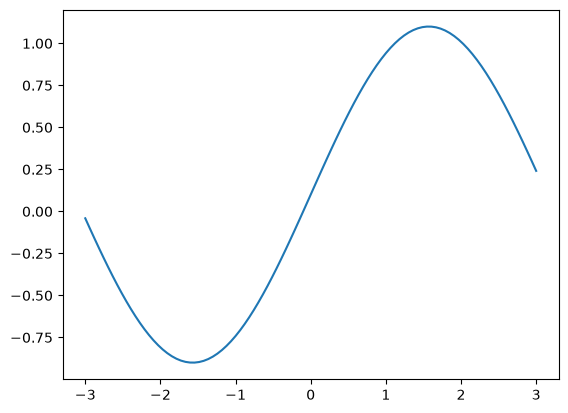

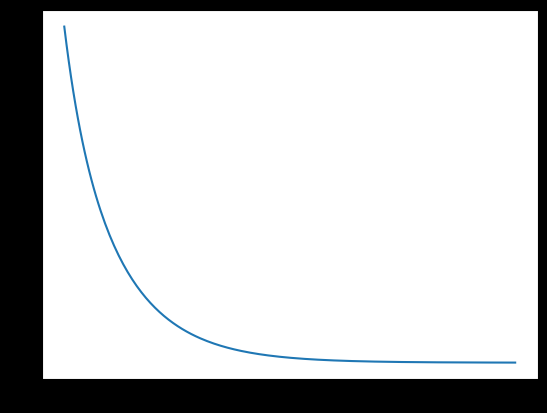

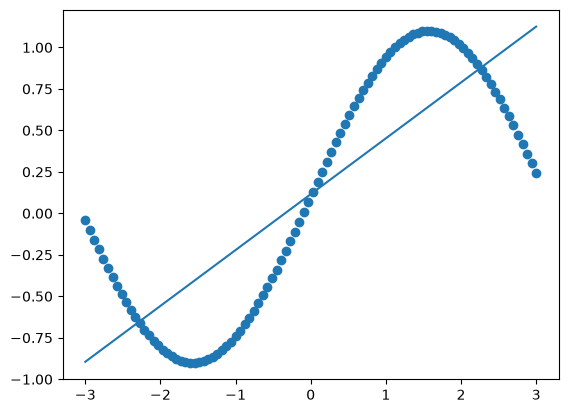

In [88]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.


x = np.linspace(-3, 3, 100)
y = np.sin(x) + 0.1

plt.plot(x, y)

# TODO: Initialise w and b to small random values.
w = random.random()
b = random.random()

lr = 0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

steps = 200
loss_arr = []

for i in range(0, steps):
    y_hat = (w * x) + b
    loss = np.mean((y_hat - y) ** 2)
    loss_arr.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db

    if i == 0:
        print("Initial weight: ", round(w, 2))
        print("Loss at 0: ", round(loss))

    if i == 1:
        print("Updated weight at point 1: ", w)
        print("Loss at 1: ", loss)

# print(loss_arr)


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# Loss curve
fig = plt.figure(facecolor='black')
plt.plot(range(0, 200), loss_arr)

# Data with the fitted line on top
plt.figure()
plt.scatter(x, y)
plt.plot(x, w * x + b)
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
1. The image of deriving `dLoss/dw` is in the project, and the `1/n` we see there is us factoring the mean into the formula; and yes it does match the code.

2. This is underfitting, because the model is way too simple (just a straight line) to capture the pattern, even on teh training data it is seeing directly. And the reason why a single neuron can never fit a sine wave is because no matter how much you train, ONE single neuron will always give you a straight line; no curves, nothing. A sine wave is the complete opposite; where you have curves at certain points. Non-linearity is what needs to be introduced to add some curve.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

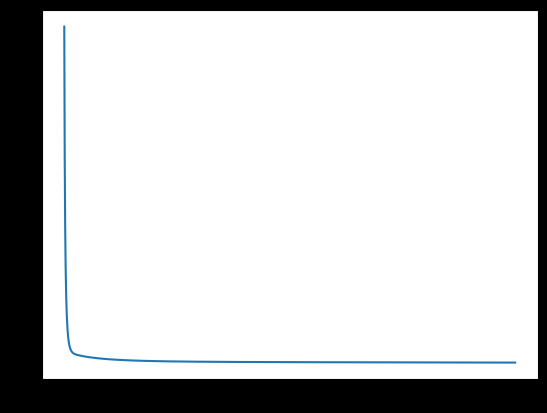

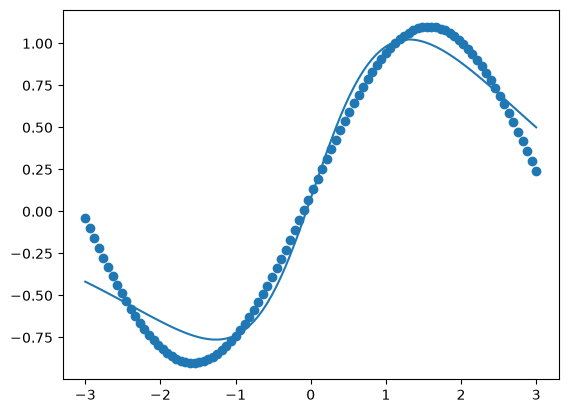

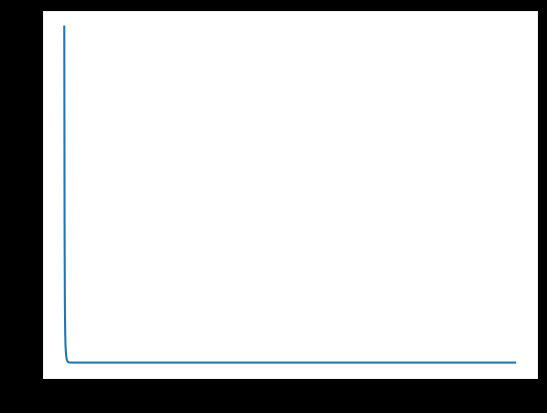

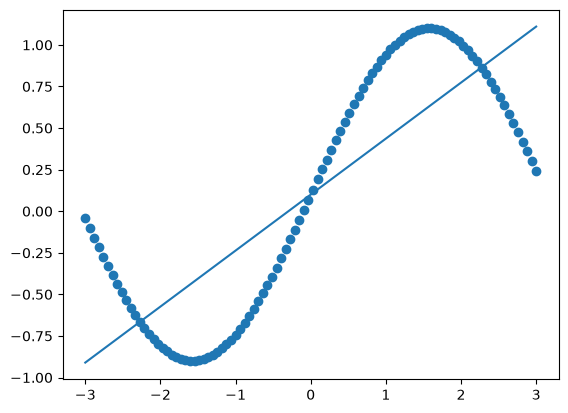

In [89]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

w1 = (np.random.randn(1, 8) * 0.5)
w2 = (np.random.randn(8, 1) * 0.5)
b1 = (np.random.randn(8,) * 0.5)
b2 = (np.random.randn(1,) * 0.5)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.


loss_arr = []

for i in range(3000):
    # forward pass
    z1 = x @ w1 + b1
    h = np.tanh(z1)
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dw2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dw1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # update weights
    w1 -= lr * dw1
    b1 -= lr * db1
    w2 -= lr * dw2
    b2 -= lr * db2

    loss_arr.append(loss)


# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

fig = plt.figure(facecolor='black')
plt.plot(range(0, 3000), loss_arr)

# Data with the fitted line on top
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_hat)
plt.show()


# Re-run with tanh removed
w1 = (np.random.randn(1, 8) * 0.5)
w2 = (np.random.randn(8, 1) * 0.5)
b1 = (np.random.randn(8,) * 0.5)
b2 = (np.random.randn(1,) * 0.5)

loss_arr = []
for i in range(3000):
    # forward pass
    z1 = x @ w1 + b1
    h = z1
    y_hat = h @ w2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dw2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * 1
    dw1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # update weights
    w1 -= lr * dw1
    b1 -= lr * db1
    w2 -= lr * dw2
    b2 -= lr * db2

    loss_arr.append(loss)

fig = plt.figure(facecolor='black')
plt.plot(range(0, 3000), loss_arr)

# Data with the fitted line on top
plt.figure()
plt.scatter(x, y)
plt.plot(x, y_hat)
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 
1. When we remove tanh, `h = z1`, which is also `x @ w1 + b1`. So our output `y_hat = h @ w2 + b2` becomes `y_hat = (x @ w1 + b1) @ w2 + b2`, which at the end of the day, if real values are substituted into it, no matter how long the equation is, it's still linear, and a line has no curvature so it can't fit a sine wave.

2. Plotting the columns of h against x shows how each neuron has learned its own S-shaped curve (that being the tanh) but they all differ in direction, steepness and position. w2 takes a weighted sum of this hidden layer's 8 neurons. When you add different kinds of s-shaped curves, that is what lets the network build up the up-and-down curve of the sine wave.

3. Back propagation is using the loss, together with the chain rule in calculus to move backwards through the network to identify how much each weight and each bias contributed to the loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/Users/danielglover/Python/IntroAISchool/NeuralNetworks-Lab3/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/zz/q0w8zdx558zfk8_xf2st9vmm0000gn/T/ipykernel_81685/1201476651.py:20: RuntimeWarning: overflow encountered in square
  l = np.mean((y_h - _y) ** 2)
/var/folders/zz/q0w8zdx558zfk8_xf2st9vmm0000gn/T/ipykernel_81685/1201476651.py:27: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2) if use_tanh else dh  # checking for if we're using tanh for not
/Users/danielglover/Python/IntroAISchool/NeuralNetworks-Lab3/.venv/lib/python3.14/site-packages/matplotlib/scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


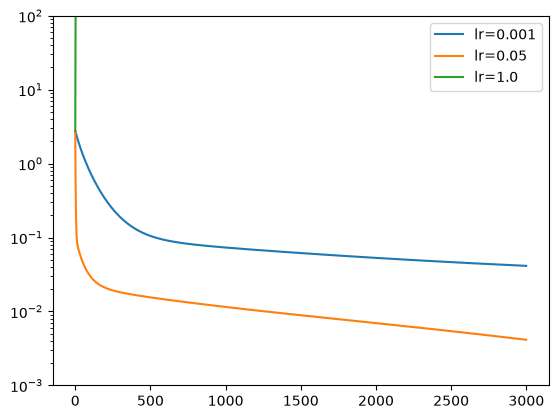

In [90]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(_x, _y, use_tanh, l_rate, s=3000, seed=42):
    np.random.seed(seed)

    w_1 = (np.random.randn(1, 8) * 0.5)
    w_2 = (np.random.randn(8, 1) * 0.5)
    b_1 = (np.random.randn(8,) * 0.5)
    b_2 = (np.random.randn(1,) * 0.5)

    l_arr = []
    y_h = 0

    for v in range(s):
        # forward pass
        z1 = _x @ w_1 + b_1
        h = np.tanh(z1) if use_tanh else z1  # checking for if we're using tanh for not
        y_h = h @ w_2 + b_2
        l = np.mean((y_h - _y) ** 2)

        # backward pass
        d_yhat = 2 * (y_h - _y) / len(_y)
        dw2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ w_2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2) if use_tanh else dh  # checking for if we're using tanh for not
        dw1 = _x.T @ dz1
        db1 = dz1.sum(axis=0)

        # updating weights
        w_1 -= l_rate * dw1
        b_1 -= l_rate * db1
        w_2 -= l_rate * dw2
        b_2 -= l_rate * db2

        l_arr.append(l)

    return l_arr, y_h # return the loss array and y_hat for plotting

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).


losses_tanh_1, yhat_tanh_1 = train_toy(x, y, use_tanh=True, l_rate=0.001)
losses_tanh_2, yhat_tanh_2  = train_toy(x, y, use_tanh=True, l_rate=0.05)
losses_tanh_3, yhat_tanh_3 = train_toy(x, y, use_tanh=True, l_rate=1.0)

# w_1, b_1, w_2, b_2 = params

# h = np.tanh(x @ w_1 + b_1)      # shape (100, 8)

# plt.figure()
# for j in range(8):
#     plt.plot(x, h[:, j], label=f"neuron {j}")
# plt.legend()
# plt.show()

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

def clean(l):
    a = np.array(l)
    a[~np.isfinite(a)] = np.nan
    return a

plt.figure()
for losses, label in [(losses_tanh_1, "lr=0.001"), (losses_tanh_2, "lr=0.05"), (losses_tanh_3, "lr=1.0")]:
    plt.plot(clean(losses), label=label)

plt.yscale("log")
plt.ylim(1e-3, 1e2)
plt.legend()
plt.show()


**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**
So the curve with learning rate 0.001 shows that it's dropping slowly, and doesn't look converged as well as the curve with learning rate of 0.05. For the one with lr = 1, it shoots straight up off the top within a few steps, showing us that it's totally diverged. As to why a large learning rate blows up the loss, first of all, the gradient tells you the slope at your current point, and the learning rate is what decides how far you trust it. You can use a valley to describe this. small sized steps move you down slowly towards the bottom. And oversized one caused by a large lr will overshoot the bottom and now land at the opposite wall, at a position probably even higher than where you came from. Then now the gradient there is even steeper and so the next step ends up overshooting further. That runaway feedback is what produced the overflow warnings we got when plotting.


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [91]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).


OBESITY_URL = "Obesity-Level-Prediction-Dataset.csv"
obesity = pd.read_csv(OBESITY_URL)


# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
obesity['family_history_with_overweight'] = obesity['family_history_with_overweight'].map({'yes': 1, 'no': 0})

obesity['FAVC'] = obesity['FAVC'].map({'yes': 1, 'no': 0})

obesity['SMOKE'] = obesity['SMOKE'].map({'yes': 1, 'no': 0})

obesity['SCC'] = obesity['SCC'].map({'yes': 1, 'no': 0})


ordinal_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(ordinal_map)
obesity['CALC'] = obesity['CALC'].map(ordinal_map)

obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True, dtype=int)

le = LabelEncoder()
obesity['NObeyesdad'] = le.fit_transform(obesity['NObeyesdad'])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

x_obe = obesity.drop(columns=['NObeyesdad']) # Representing every column except the target
y_obe = obesity['NObeyesdad'] # Just the target


x_train, x_test, y_train, y_test = train_test_split(x_obe, y_obe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_obe, shuffle=True)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train, shuffle=True)


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

sc = StandardScaler()


num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

x_train[num_cols] = sc.fit_transform(x_train[num_cols]) # Scaling on just training

# Transform just val & test
x_val[num_cols] = sc.transform(x_val[num_cols])
x_test[num_cols] = sc.transform(x_test[num_cols])

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

x_train_t = torch.tensor(x_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t = torch.tensor(x_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

X_test_t = torch.tensor(x_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)


train_ds = TensorDataset(x_train_t, y_train_t)
val_ds  = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

print(len(train_ds), len(val_ds), len(test_ds))
print(x_train_t.shape, X_val_t.shape, X_test_t.shape)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader  = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


1266 422 423
torch.Size([1266, 19]) torch.Size([422, 19]) torch.Size([423, 19])


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
1. CrossEntropyLoss needs integer class labels rather than the one-hot vectors because it all comes down to efficiency. When we get our output logits (which is turned into log-probabilities), they're compared to our one-hot target, which has 1 for the right class, and zero for the rest. The calculation is a sum over all the classes, but in the end the zero ones all vanish, leaving the 1. So all Pytorch wants is the index of the non-zero, and use that to index into the log-probability vector rather than computing mostly-zero sums.

2. Neural networks care a lot about feature scaling because the gradients' magnitude scales with the feature magnitude. Weight for instance, would produce gradients way larger than that of let's say Height for instance. When this becomes the case, you can't use one shared learning rate for all, training would become unstable. That's why feature scaling is so important because it puts all the features on common ground/footing.

3. shuffle=True on the training DataLoader shuffles the dataset on every iteration (epoch) in training because the order matters, in the sense that the batch order affects the gradient sequence and update path. If the data isn't shuffled, it means that we'll have the same sequence of correlated updates, which can move the model towards a poor trajectory. Shuffling brings about randomness.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        # at least 2 hidden layers
        dims = [input_dim, *hidden_sizes, n_classes]
        layers = []

        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if not i == len(dims) - 2:
                layers.append(nn.ReLU())

        self.net = nn.Sequential(*layers)

        



    def forward(self, x):
        return self.net(x)

# TODO: Instantiate, move to DEVICE, print the model.

model = FeedForwardNet(input_dim=x_train_t.shape[1]).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

print(sum(p.numel() for p in model.parameters() if p.requires_grad))
# Output was 3591, and input _dim * 64 + 64 is 1280 for the first layer

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
3591


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 
1. first layer = `19 * 64 + 64 => 1280`. Second layer = `64 * 32 + 32 => 2080`. Last layer = `32 * 7 + 7 => 231`. Summing all 3 up: `1280 + 2080 + 231 = 3591` which matches PyTorch exactly.

2. An advantage of ReLU here over tanh is fast computing. It basically uses a simple threshold check rather than long math computations

3. It would collapse to a single linear transformation like we proved in 1.2, so it'll be all linear layers without any curves (non-linearity)

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Loss (Training): 1.841092901395584, Accuracy (Training): 0.31516587677725116 ---------- Loss (Val): 1.8439013082269244, Accuracy (Val): 0.3246445497630332
Loss (Training): 1.5942943469043027, Accuracy (Training): 0.5165876777251185 ---------- Loss (Val): 1.5979254274006705, Accuracy (Val): 0.5379146919431279
Loss (Training): 1.1895219548995273, Accuracy (Training): 0.608214849921011 ---------- Loss (Val): 1.1889945743208248, Accuracy (Val): 0.6421800947867299
Loss (Training): 0.9218430514395896, Accuracy (Training): 0.617693522906793 ---------- Loss (Val): 0.9197360531413724, Accuracy (Val): 0.6516587677725119
Loss (Training): 0.7379311294917247, Accuracy (Training): 0.7717219589257504 ---------- Loss (Val): 0.7438724953416399, Accuracy (Val): 0.7535545023696683
Loss (Training): 0.6112083918863751, Accuracy (Training): 0.8151658767772512 ---------- Loss (Val): 0.6225223665553812, Accuracy (Val): 0.7985781990521327
Loss (Training): 0.5250186153686065, Accuracy (Training): 0.819115323854

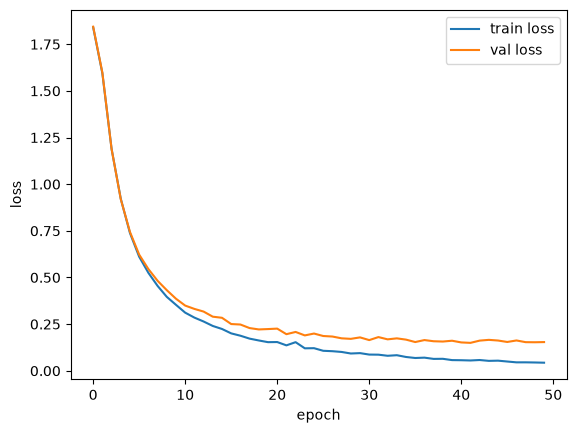

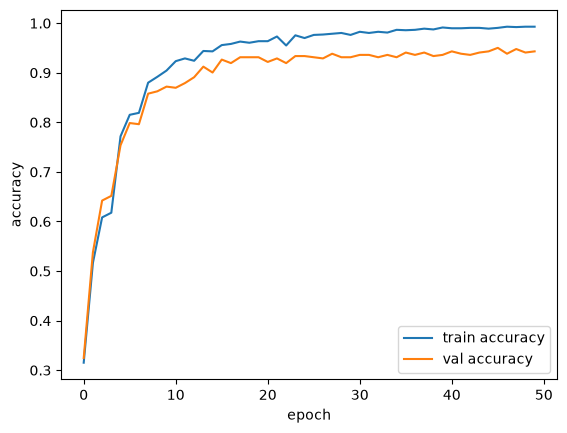

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# function to run eval every epoch
def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0, 0, 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(yb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            n += len(yb)

    return total_loss / n, correct / n


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

model.train()
training_history = []

for i in range(0, 50):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()

    tr_loss, tr_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)


    training_history.append((tr_loss, tr_acc, val_loss, val_acc))
    print(f"Loss (Training): {tr_loss}, Accuracy (Training): {tr_acc} ---------- Loss (Val): {val_loss}, Accuracy (Val): {val_acc}")

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
tr_losses = [h[0] for h in training_history]
tr_accs = [h[1] for h in training_history]
val_losses = [h[2] for h in training_history]
val_accs = [h[3] for h in training_history]

# figure 1: Loss
plt.figure()

plt.plot(tr_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss")

plt.legend()
plt.show()


# figure 2: Accuracy
plt.figure()

plt.plot(tr_accs, label="train accuracy")
plt.plot(val_accs, label="val accuracy")
plt.xlabel("epoch"); plt.ylabel("accuracy")

plt.legend()
plt.show()



**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 
1. So the forward pass would be from `logits = model(xb.to(DEVICE)) -> z1 = x @ w_1 + b_1; h = tanh(z1); y_h = h @ w_2 + b_2` to `loss = criterion(logits, yb.to(DEVICE)) -> l = np.mean((y_h - _y) ** 2)`. Then the backward pass starts from `loss.backward() -> maps out to the whole backward block`, where the gradients are computed, and then we update them using `optimizer.step() -> w_1 -= l_rate * dw1`.

2. It looks like the mode might be overfitting, but slightly. The reason being that training accuract ends at 99.3% but validation reaches 94%, which is not bad but the loss numbers show it more, that the val loss is about 3x more than the train loss (0.043 train vs 0.143 val).

3. Every time we call `loss.backward()`, what we're doing is to update whatever values were stored in our gradient attribute of our parameters. And so we call `optimizer.zero_grad()` every batch because we need to clear those old gradients before we do the next backward pass, or else the model will combine new gradients with the old ones, and that leads to incorrect weight updates and messes up our training.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [94]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [95]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.